<div style="background-color: #1F3864; padding: 20px; border-radius: 5px; margin-bottom: 20px;">
    <h1 style="color: white; margin: 0; font-size: 24px;">MPI-GE JJAS Extreme Rainfall Extraction</h1>
    <p style="color: #cce0ff; margin: 8px 0 0 0; font-size: 14px;">Rx5day | India domain (8-35N, 68-99E) | ETCCDI definitions (Zhang et al. 2011)</p>
</div>

In [1]:
import xarray as xr
import numpy as np
import glob
import os
import xclim.indices as xci
import xclim
import geopandas as gpd
import matplotlib.pyplot as plt

print('All imports successful')
print(f'xclim version: {xclim.__version__}')

All imports successful
xclim version: 0.53.2


In [2]:
# File paths
# Path to anthropogenic (historical) daily precipitation files
HIST_PATH = '/data/oacd/smiles/MPI/historical/pr_day/'

# Path to natural-forcing-only (hist-nat) daily precipitation files
NAT_PATH = '/data/oacd/smiles/MPI/hist-nat/pr_day/'

# Path to near-future SSP2-4.5 daily precipitation files
SSP245_PATH = '/data/oacd/smiles/MPI/ssp245/pr_day/'

# Where to save outputs
OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Ensemble members
# 30 member labels matching the filenames on the cluster
MEMBERS = [f'r{i}i1p1f1' for i in range(1, 31)]

# India spatial domain 
# Covers all four monsoon regions: Western Ghats, Central India, IGP, Northeast
LAT_MIN, LAT_MAX = 8, 35
LON_MIN, LON_MAX = 68, 99

# Monsoon season
# JJAS only — all four study regions are summer-monsoon dominated
JJAS = [6, 7, 8, 9]

print('Configuration set')
print(f'Members: {MEMBERS[0]} to {MEMBERS[-1]}')
print(f'India domain: lat {LAT_MIN}-{LAT_MAX}N, lon {LON_MIN}-{LON_MAX}E')
print(f'Season: months {JJAS}')
print(f'Output directory: {OUTPUT_DIR}')

Configuration set
Members: r1i1p1f1 to r30i1p1f1
India domain: lat 8-35N, lon 68-99E
Season: months [6, 7, 8, 9]
Output directory: /home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/


In [3]:
import xarray as xr, glob, os

one_file = sorted(glob.glob(os.path.join(HIST_PATH, '*r1i1p1f1*.nc')))[0]
ds_check = xr.open_dataset(one_file)
print("Raw file lat range:", float(ds_check.lat.min()), "to", float(ds_check.lat.max()))
print("Raw file lon range:", float(ds_check.lon.min()), "to", float(ds_check.lon.max()))
ds_check.close()

Raw file lat range: -88.57216851400727 to 88.57216851400727
Raw file lon range: 0.0 to 358.125


In [4]:
def extract_rx_jjas(member, base_path, label):
    """
    Extracts JJAS-season Rx5day for one ensemble member.
    
    Parameters
    
    member : str      e.g. 'r1i1p1f1'
    base_path : str   path to directory containing daily pr .nc files
    label : str       'ant', 'nat', or 'ssp245' — used in print messages
    
    Returns
    
    rx5day : xr.DataArray  shape (year, lat, lon)
    """
    
    # Find all .nc files for this member in the given directory
    files = sorted(glob.glob(os.path.join(base_path, f'*{member}*.nc')))
    if len(files) == 0:
        raise FileNotFoundError(f'No files found for {member} in {base_path}')
    
    # Stitch all files into one continuous time series
    ds = xr.open_mfdataset(files, combine='by_coords', chunks={'time': 365})
    
    # Convert kg/m2/s to mm/day and cut out the India domain
    pr = (ds['pr'] * 86400).sel(lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX))
    
    # Filter to JJAS months only
    pr_jjas = pr.sel(time=pr.time.dt.month.isin(JJAS))
    
    # xclim requires a units attribute
    pr_jjas.attrs['units'] = 'mm/day'
    
    # Rx5day — max 5-day accumulated precipitation per year (ETCCDI definition via xclim)
    rx5day = xci.max_n_day_precipitation_amount(pr_jjas, window=5, freq='YS')
    rx5day.name = 'rx5day'
    
    return rx5day

print('Extraction function defined')

Extraction function defined


In [19]:
# Test the extraction function on one member before running the full loop
print('Testing extraction on r1i1p1f1 (anthropogenic)...')

rx5day_test = extract_rx_jjas('r1i1p1f1', HIST_PATH, 'ant')

# Force computation and print sanity checks
rx5day_test_computed = rx5day_test.compute()

print(f'Rx5day shape: {dict(rx5day_test_computed.sizes)}')
print(f'Years: {rx5day_test_computed.time.values[0]} to {rx5day_test_computed.time.values[-1]}')
print(f'Rx5day mean: {float(rx5day_test_computed.mean()):.1f} mm')
print(f'Rx5day max: {float(rx5day_test_computed.max()):.1f} mm')
print(f'Rx5day min: {float(rx5day_test_computed.min()):.1f} mm')

Testing extraction on r1i1p1f1 (anthropogenic)...
Rx5day shape: {'time': 165, 'lat': 15, 'lon': 16}
Years: 1850-01-01T00:00:00.000000000 to 2014-01-01T00:00:00.000000000
Rx5day mean: 1619.8 mm
Rx5day max: 25704.0 mm
Rx5day min: 0.0 mm


In [5]:
print('Rx5day units:', rx5day_test_computed.attrs.get('units', 'no units attr'))

# Also check a single grid cell time series to see raw values
print('\nSample Rx5day values at one grid cell (mm):')
print(rx5day_test_computed.isel(lat=6, lon=7).values[:10])

NameError: name 'rx5day_test_computed' is not defined

In [13]:
# Build a JJAS-filtered, unit-converted precip series for one member,
# used below to test xclim's built-in Rx5day function against a manual computation
pr_test = (xr.open_mfdataset(
    sorted(glob.glob(os.path.join(HIST_PATH, '*r1i1p1f1*.nc'))),
    combine='by_coords', chunks={'time': 365}
)['pr'] * 86400).sel(lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX))

pr_jjas_test = pr_test.sel(time=pr_test.time.dt.month.isin(JJAS))
pr_jjas_test.attrs['units'] = 'mm/day'

# Look at sample daily values at one grid cell
sample = pr_jjas_test.isel(lat=6, lon=7).compute()
print('Sample daily pr values (mm/day):')
print(sample.values[:20])
print(f'Mean daily pr: {float(sample.mean()):.2f} mm/day')
print(f'Max daily pr: {float(sample.max()):.2f} mm/day')
print(f'Number of days: {len(sample)}')

Sample daily pr values (mm/day):
[1.3542258e-13 1.1645729e-13 1.3055823e-13 1.2976253e-13 1.3826360e-13
 1.2486712e-13 1.3427338e-13 1.2136704e-13 1.2131222e-13 1.2367262e-13
 1.2268891e-13 8.0063939e-03 3.6242561e+00 1.1158483e-13 3.0899048e-02
 3.6821365e-01 9.5742285e-02 7.5060949e+00 2.0334652e+01 6.7478862e+00]
Mean daily pr: 6.75 mm/day
Max daily pr: 56.06 mm/day
Number of days: 20130


In [14]:
# Compare a manual Rx5day computation against xclim's built-in function
pr_jjas_test.attrs['units'] = 'mm/day'

# Manual: rolling 5-day sum, then annual max
manual_rx5day = pr_jjas_test.rolling(time=5, min_periods=5).sum().groupby('time.year').max(dim='time').compute()

print('Manual Rx5day sample values:', manual_rx5day.isel(lat=6, lon=7).values[:5])
print('Manual Rx5day mean:', float(manual_rx5day.mean()))

# xclim's built-in Rx5day function
xclim_rx5day = xci.max_n_day_precipitation_amount(pr_jjas_test, window=5, freq='YS').compute()
print('xclim Rx5day sample values:', xclim_rx5day.isel(lat=6, lon=7).values[:5])
print('xclim Rx5day mean:', float(xclim_rx5day.mean()))

Manual Rx5day sample values: [ 88.63377  111.113785 157.39302  102.45347  135.61154 ]
Manual Rx5day mean: 122.42224884033203
xclim Rx5day sample values: [ 500.91442323 1126.27902627 1125.94322544 1672.58659744 1829.88624483]
xclim Rx5day mean: 1619.848022079617


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <p style="color: #cce0ff; margin: 0; font-size: 13px;">xclim's max_n_day_precipitation_amount returns Rx5day values roughly 13x too high for this JJAS-only, India-domain input (mean 1620mm vs 122mm manual). Deciding to switch to a manual rolling-sum computation below.</p>
</div>

In [6]:
# xclim's max_n_day_precipitation_amount gives Rx5day ~13x too high here
# (mean 1620mm vs 122mm manual, tested above) - switching to manual
# rolling-sum computation below
def extract_rx_jjas(member, base_path, label):
    """
    Extracts JJAS-season Rx5day for one ensemble member.
    Uses manual computation following ETCCDI definitions (Zhang et al. 2011).
    
    Parameters
    ----------
    member : str      e.g. 'r1i1p1f1'
    base_path : str   path to directory containing daily pr .nc files
    label : str       'ant', 'nat', or 'ssp245'
    
    Returns
    -------
    rx5day : xr.DataArray  shape (time, lat, lon) — time = years
    """
    
    # Find and stitch all files for this member into one time series
    files = sorted(glob.glob(os.path.join(base_path, f'*{member}*.nc')))
    if len(files) == 0:
        raise FileNotFoundError(f'No files found for {member} in {base_path}')
    
    # Open all files as one continuous dataset
    ds = xr.open_mfdataset(files, combine='by_coords', chunks={'time': 365})
    
    # Convert kg/m2/s to mm/day and cut out the India domain
    pr = (ds['pr'] * 86400).sel(lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX))
    
    # Filter to JJAS months only (June, July, August, September)
    pr_jjas = pr.sel(time=pr.time.dt.month.isin(JJAS))
    
    # Rx5day — maximum 5-day accumulated precipitation within each JJAS season
    # ETCCDI definition: Rx5dayj = max(RRkj) where RRkj is the 5-day interval sum
    # Rolling sum computed across JJAS days, then annual maximum taken
    rx5day = pr_jjas.rolling(time=5, min_periods=5).sum().groupby('time.year').max(dim='time')
    rx5day.name = 'rx5day'
    rx5day.attrs['units'] = 'mm'
    rx5day.attrs['long_name'] = 'Annual maximum 5-day JJAS precipitation accumulation'
    
    return rx5day

print('Extraction function redefined to use manual rolling-sum computation')

Extraction function redefined to use manual rolling-sum computation


In [17]:
# Test the updated function on one member
print('Testing updated function on r1i1p1f1...')

rx5day_test = extract_rx_jjas('r1i1p1f1', HIST_PATH, 'ant')
rx5day_computed = rx5day_test.compute()

print(f'Rx5day shape: {dict(rx5day_computed.sizes)}')
print(f'Rx5day mean: {float(rx5day_computed.mean()):.1f} mm')
print(f'Rx5day max: {float(rx5day_computed.max()):.1f} mm')
print(f'Rx5day min: {float(rx5day_computed.min()):.1f} mm')
print(f'Sample Rx5day values at one grid cell: {rx5day_computed.isel(lat=6, lon=7).values[:5]}')

Testing updated function on r1i1p1f1...
Rx5day shape: {'year': 165, 'lat': 15, 'lon': 16}
Rx5day mean: 122.4 mm
Rx5day max: 761.2 mm
Rx5day min: 0.0 mm
Sample Rx5day values at one grid cell: [ 88.63377  111.113785 157.39302  102.45347  135.61154 ]


<div style="background-color: #1F3864; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h1 style="color: white; margin: 0; font-size: 20px;">1. JJAS Extraction - Anthropogenic Members</h1>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Historical forcing (1850-2014) | 30 members | Output: rx5day_jjas_ant_all.nc</p>
</div>

In [21]:
# Run full extraction for all 30 anthropogenic members
print('Extracting JJAS Rx5day: ANTHROPOGENIC members\n')

all_rx5day_ant = []

for member in MEMBERS:
    print(f'Processing {member}...')
    rx5day = extract_rx_jjas(member, HIST_PATH, 'ant')
    
    # Compute and store
    all_rx5day_ant.append(rx5day)
    print(f'  Done: Rx5day mean = {float(rx5day.mean().compute()):.1f} mm')

# Stack all 30 members into single array
print('\nStacking all anthropogenic members...')
rx5day_ant = xr.concat(all_rx5day_ant, dim='member').assign_coords(member=MEMBERS)

# Save to netCDF
rx5day_ant.to_netcdf(os.path.join(OUTPUT_DIR, 'rx5day_jjas_ant_all.nc'))

print(f'\nFinal shape:')
print(f'  rx5day_ant: {dict(rx5day_ant.sizes)}')
print('\nDone. Anthropogenic members saved.')

Extracting JJAS Rx5day: ANTHROPOGENIC members

Processing r1i1p1f1...
  Done: Rx5day mean = 1619.8 mm
Processing r2i1p1f1...
  Done: Rx5day mean = 1571.5 mm
Processing r3i1p1f1...
  Done: Rx5day mean = 1453.4 mm
Processing r4i1p1f1...
  Done: Rx5day mean = 1635.1 mm
Processing r5i1p1f1...
  Done: Rx5day mean = 1560.4 mm
Processing r6i1p1f1...
  Done: Rx5day mean = 1534.5 mm
Processing r7i1p1f1...
  Done: Rx5day mean = 1614.8 mm
Processing r8i1p1f1...
  Done: Rx5day mean = 1558.5 mm
Processing r9i1p1f1...
  Done: Rx5day mean = 1515.0 mm
Processing r10i1p1f1...
  Done: Rx5day mean = 1584.0 mm
Processing r11i1p1f1...
  Done: Rx5day mean = 1601.3 mm
Processing r12i1p1f1...
  Done: Rx5day mean = 1521.0 mm
Processing r13i1p1f1...
  Done: Rx5day mean = 1551.3 mm
Processing r14i1p1f1...
  Done: Rx5day mean = 1591.0 mm
Processing r15i1p1f1...
  Done: Rx5day mean = 1517.1 mm
Processing r16i1p1f1...


KeyboardInterrupt: 

In [22]:
# Confirm the anthropogenic Rx5day output was written
ant_file = os.path.join(OUTPUT_DIR, 'rx5day_jjas_ant_all.nc')
size_mb = os.path.getsize(ant_file) / (1024**2)
print(f'rx5day_jjas_ant_all.nc: {size_mb:.1f} MB')

rx5day_jjas_ant_all.nc: 4.5 MB


In [23]:
check = xr.open_dataarray(os.path.join(OUTPUT_DIR, 'rx5day_jjas_ant_all.nc'))
print("Shape:", dict(check.sizes))
print("Lat range:", float(check.lat.min()), "to", float(check.lat.max()))
print("Lon range:", float(check.lon.min()), "to", float(check.lon.max()))
print("Mean Rx5day:", float(check.mean()), "mm")

Shape: {'member': 30, 'year': 165, 'lat': 15, 'lon': 16}
Lat range: 8.393668907692383 to 34.50724334150103
Lon range: 69.375 to 97.5
Mean Rx5day: 122.3907470703125 mm


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">2. JJAS Extraction - Natural-Forcing Members (hist-nat)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Natural forcing only - solar and volcanic, no anthropogenic GHGs (1850-2014) | 30 members | Output: rx5day_jjas_nat_all.nc</p>
</div>

In [ ]:
# Run full extraction for all 30 natural-forcing (hist-nat) members
print('Extracting JJAS Rx5day: NATURAL-FORCING members\n')

all_rx5day_nat = []

for member in MEMBERS:
    print(f'Processing {member}...')
    rx5day = extract_rx_jjas(member, NAT_PATH, 'nat')
    all_rx5day_nat.append(rx5day)
    print(f'  Done: Rx5day mean = {float(rx5day.mean().compute()):.1f} mm')

# Stack all 30 members
print('\nStacking all natural-forcing members...')
rx5day_nat = xr.concat(all_rx5day_nat, dim='member').assign_coords(member=MEMBERS)

# Save to netCDF
rx5day_nat.to_netcdf(os.path.join(OUTPUT_DIR, 'rx5day_jjas_nat_all.nc'))

print(f'\nFinal shape:')
print(f'  rx5day_nat: {dict(rx5day_nat.sizes)}')
print('\nDone. Natural-forcing members saved.')

=== Extracting JJAS Rx5day: NATURAL-FORCING members ===

Processing r1i1p1f1...
  Done: Rx5day mean = 121.6 mm
Processing r2i1p1f1...
  Done: Rx5day mean = 121.9 mm
Processing r3i1p1f1...
  Done: Rx5day mean = 122.4 mm
Processing r4i1p1f1...
  Done: Rx5day mean = 122.3 mm
Processing r5i1p1f1...
  Done: Rx5day mean = 121.9 mm
Processing r6i1p1f1...
  Done: Rx5day mean = 122.0 mm
Processing r7i1p1f1...
  Done: Rx5day mean = 122.2 mm
Processing r8i1p1f1...
  Done: Rx5day mean = 121.5 mm
Processing r9i1p1f1...
  Done: Rx5day mean = 122.7 mm
Processing r10i1p1f1...
  Done: Rx5day mean = 121.4 mm
Processing r11i1p1f1...
  Done: Rx5day mean = 122.0 mm
Processing r12i1p1f1...
  Done: Rx5day mean = 121.7 mm
Processing r13i1p1f1...
  Done: Rx5day mean = 121.5 mm
Processing r14i1p1f1...
  Done: Rx5day mean = 122.5 mm
Processing r15i1p1f1...
  Done: Rx5day mean = 122.2 mm
Processing r16i1p1f1...
  Done: Rx5day mean = 122.1 mm
Processing r17i1p1f1...
  Done: Rx5day mean = 121.9 mm
Processing r18i1p

In [24]:
# Confirm the natural-forcing Rx5day output was written
nat_file = os.path.join(OUTPUT_DIR, 'rx5day_jjas_nat_all.nc')
size_mb = os.path.getsize(nat_file) / (1024**2)
print(f'rx5day_jjas_nat_all.nc: {size_mb:.1f} MB')

rx5day_jjas_nat_all.nc: 4.5 MB


In [25]:
rx5day_nat = xr.open_dataarray(os.path.join(OUTPUT_DIR, 'rx5day_jjas_nat_all.nc'))

print(f'rx5day_nat shape: {dict(rx5day_nat.sizes)}')
print(f'rx5day_nat mean: {float(rx5day_nat.mean()):.1f} mm')
print(f'Years: {rx5day_nat.year.values[0]} to {rx5day_nat.year.values[-1]}')
print(f'Members: {rx5day_nat.member.values[0]} to {rx5day_nat.member.values[-1]}')

rx5day_nat shape: {'member': 30, 'year': 165, 'lat': 15, 'lon': 16}
rx5day_nat mean: 121.8 mm
Years: 1850 to 2014
Members: r1i1p1f1 to r30i1p1f1


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">3. JJAS Extraction - Near-Future Members (SSP2-4.5)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Near-future projection (2015-2100) | 30 members | Output: rx1day_jjas_ssp245_all.nc, rx5day_jjas_ssp245_all.nc</p>
</div>

In [ ]:
# Run full extraction for all 30 SSP2-4.5 members (near-future, 2015-2100)
print('Extracting JJAS Rx5day: SSP2-4.5 members\n')

all_rx5day_ssp = []

for member in MEMBERS:
    print(f'Processing {member}...')
    rx5day = extract_rx_jjas(member, SSP245_PATH, 'ssp245')
    all_rx5day_ssp.append(rx5day)
    print(f'  Done: Rx5day mean = {float(rx5day.mean().compute()):.1f} mm')

# Stack all 30 members
print('\nStacking all SSP2-4.5 members...')
rx5day_ssp = xr.concat(all_rx5day_ssp, dim='member').assign_coords(member=MEMBERS)

# Save to netCDF
rx5day_ssp.to_netcdf(os.path.join(OUTPUT_DIR, 'rx5day_jjas_ssp245_all.nc'))

print(f'\nFinal shape:')
print(f'  rx5day_ssp: {dict(rx5day_ssp.sizes)}')
print('\nDone. SSP2-4.5 members saved.')

=== Extracting JJAS Rx5day: SSP2-4.5 members ===

Processing r1i1p1f1...
  Done: Rx5day mean = 130.2 mm
Processing r2i1p1f1...
  Done: Rx5day mean = 128.5 mm
Processing r3i1p1f1...
  Done: Rx5day mean = 129.1 mm
Processing r4i1p1f1...
  Done: Rx5day mean = 129.0 mm
Processing r5i1p1f1...
  Done: Rx5day mean = 128.3 mm
Processing r6i1p1f1...
  Done: Rx5day mean = 127.9 mm
Processing r7i1p1f1...
  Done: Rx5day mean = 128.5 mm
Processing r8i1p1f1...
  Done: Rx5day mean = 128.8 mm
Processing r9i1p1f1...
  Done: Rx5day mean = 128.8 mm
Processing r10i1p1f1...
  Done: Rx5day mean = 128.0 mm
Processing r11i1p1f1...
  Done: Rx5day mean = 129.4 mm
Processing r12i1p1f1...
  Done: Rx5day mean = 128.3 mm
Processing r13i1p1f1...
  Done: Rx5day mean = 128.2 mm
Processing r14i1p1f1...
  Done: Rx5day mean = 129.4 mm
Processing r15i1p1f1...
  Done: Rx5day mean = 129.7 mm
Processing r16i1p1f1...
  Done: Rx5day mean = 128.6 mm
Processing r17i1p1f1...
  Done: Rx5day mean = 128.8 mm
Processing r18i1p1f1...


In [ ]:
# Confirm the SSP2-4.5 Rx5day output was written
ssp_file = os.path.join(OUTPUT_DIR, 'rx5day_jjas_ssp245_all.nc')
size_mb = os.path.getsize(ssp_file) / (1024**2)
print(f'rx5day_jjas_ssp245_all.nc: {size_mb:.1f} MB')

In [ ]:
rx5day_ssp = xr.open_dataarray(os.path.join(OUTPUT_DIR, 'rx5day_jjas_ssp245_all.nc'))

print(f'rx5day_ssp shape: {dict(rx5day_ssp.sizes)}')
print(f'rx5day_ssp mean: {float(rx5day_ssp.mean()):.1f} mm')
print(f'Years: {rx5day_ssp.year.values[0]} to {rx5day_ssp.year.values[-1]}')
print(f'Members: {rx5day_ssp.member.values[0]} to {rx5day_ssp.member.values[-1]}')

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">4. Grid Coverage Check</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Mean Rx5day over the extracted MPI-GE grid, with regional boundaries for context (see 03_regional_masks_and_approachA for the full masking workflow)</p>
</div>

In [ ]:
import geopandas as gpd

path = "/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/gadm/gadm41_IND.gpkg"

gdf = gpd.read_file(path, layer="ADM_ADM_1")

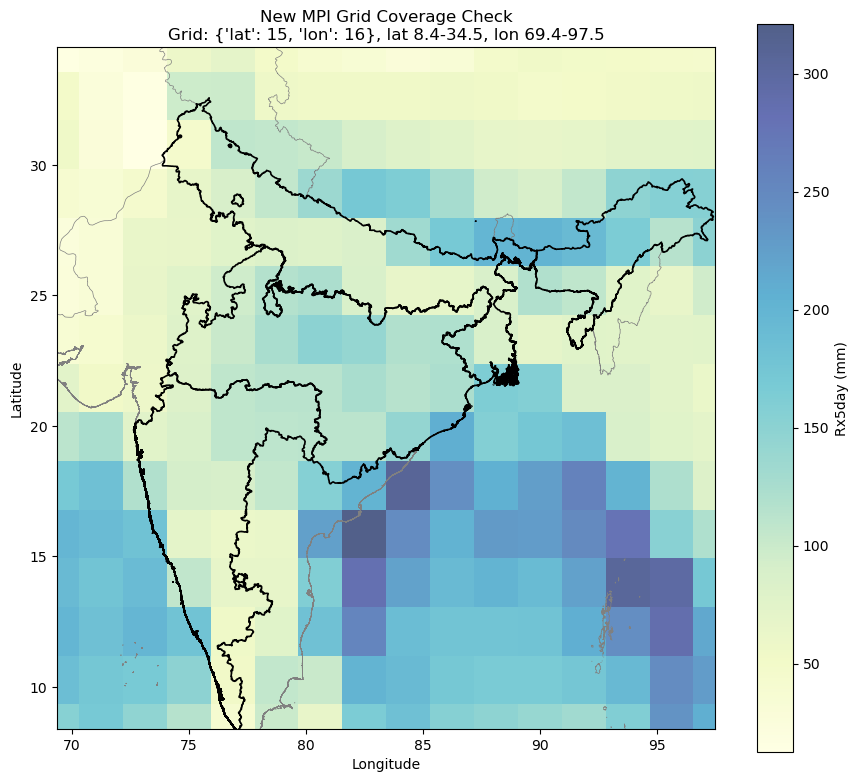

In [28]:
rx5day_ant_check = xr.open_dataarray(os.path.join(OUTPUT_DIR, 'rx5day_jjas_ant_all.nc'))

# Region boundaries for context (same GADM source used throughout)
gadm_path = "/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/gadm/gadm41_IND.gpkg"
gdf = gpd.read_file(gadm_path, layer="ADM_ADM_1")
gdf_clean = gdf.dissolve(by="NAME_1")

region_states = {
    'Western_Ghats': ['Kerala', 'Karnataka', 'Goa', 'Maharashtra'],
    'Central_India': ['Madhya Pradesh', 'Chhattisgarh', 'Odisha', 'Jharkhand'],
    'Indo_Gangetic_Plain': ['Uttar Pradesh', 'Bihar', 'West Bengal', 'Punjab', 'Haryana'],
    'Northeast': ['Assam', 'Meghalaya', 'Arunachal Pradesh', 'Tripura']
}
state_to_region = {state: region for region, states in region_states.items() for state in states}
gdf_clean['region'] = gdf_clean.index.map(state_to_region)
gdf_regions = gdf_clean[gdf_clean['region'].notna()].dissolve(by='region')

# Plot: mean Rx5day, showing the actual grid extent, with region + national outlines
fig, ax = plt.subplots(figsize=(9, 8))

mean_map = rx5day_ant_check.mean(dim=['member', 'year'])
im = ax.pcolormesh(mean_map.lon, mean_map.lat, mean_map, cmap='YlGnBu', shading='nearest', alpha=0.7)

gdf_clean.dissolve().boundary.plot(ax=ax, color='grey', linewidth=0.5)
for region in region_states.keys():
    gdf_regions.loc[[region]].boundary.plot(ax=ax, color='black', linewidth=1.2)

ax.set_xlim(float(mean_map.lon.min()), float(mean_map.lon.max()))
ax.set_ylim(float(mean_map.lat.min()), float(mean_map.lat.max()))
ax.set_title(f'New MPI Grid Coverage Check\nGrid: {dict(mean_map.sizes)}, lat {float(mean_map.lat.min()):.1f}-{float(mean_map.lat.max()):.1f}, lon {float(mean_map.lon.min()):.1f}-{float(mean_map.lon.max()):.1f}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(im, ax=ax, label='Rx5day (mm)')
plt.tight_layout()
plt.show()